# Bayesian Optimization

In [1]:
import sys
sys.path.append("..")

import uproot 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy.stats as st
import pandas as pd

from sklearn.metrics import mean_squared_error

In [2]:
f = uproot.open("../datasets/hist.root")
tree = f['tnt']

photon_pt = np.asarray(tree['a_pt'].array())
photon_eta = np.asarray(tree['a_eta'].array())
photon_phi = np.asarray(tree['a_phi'].array())

jet_pt = np.asarray(tree['j_pt'].array())
jet_eta = np.asarray(tree['j_eta'].array())
jet_phi = np.asarray(tree['j_phi'].array())

photon_threeM = []
jet_threeM = []

nevents = photon_pt.shape[0]
for i in range(nevents):
    if ((photon_pt[i] > 20) and (jet_pt[i] > 20)):
        photon_threeM.append([photon_pt[i], photon_eta[i], photon_phi[i]])
        jet_threeM.append([jet_pt[i], jet_eta[i], jet_phi[i]])
        
photon_threeM = np.asarray(photon_threeM)
jet_threeM = np.asarray(jet_threeM)

f.close()

### Efficiency of MET < 10

In [3]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

In [4]:
def Eff_MET10(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        j_pt = jet_threeM[i, 0] / jet_scale
        met_x = a_pt * np.cos(photon_threeM[i, 2]) + j_pt * np.cos(jet_threeM[i, 2])
        met_y = a_pt * np.sin(photon_threeM[i, 2]) + j_pt * np.sin(jet_threeM[i, 2])
        met = np.sqrt(met_x * met_x + met_y * met_y)
        if met < 10:
            count += 1
    return count / len(photon_threeM)


def Eff_MET10_sigmoid(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        j_pt = jet_threeM[i, 0] / jet_scale
        met_x = a_pt * np.cos(photon_threeM[i, 2]) + j_pt * np.cos(jet_threeM[i, 2])
        met_y = a_pt * np.sin(photon_threeM[i, 2]) + j_pt * np.sin(jet_threeM[i, 2])
        met = np.sqrt(met_x * met_x + met_y * met_y)
        count += sigmoid(-(met-10.0))
    return count / len(photon_threeM)


def dEff_MET10_sigmoid(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count_da = 0
    count_dj = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        a_phi = photon_threeM[i, 2]
        j_pt = jet_threeM[i, 0] / jet_scale
        j_phi = jet_threeM[i, 2]
        met_x = a_pt * np.cos(a_phi) + j_pt * np.cos(j_phi)
        met_y = a_pt * np.sin(a_phi) + j_pt * np.sin(j_phi)
        met = np.sqrt(met_x * met_x + met_y * met_y)
        
        dsig = -dsigmoid(-(met-10.0))
        dmet = 0.5 / met 
        # wrt photon 
        dmet_da  = -2*met_x*photon_threeM[i, 0] * np.cos(a_phi) / photon_scale**2
        dmet_da += -2*met_y*photon_threeM[i, 0] * np.sin(a_phi) / photon_scale**2
        #wrt jet 
        dmet_dj  = -2*met_x*jet_threeM[i, 0] * np.cos(j_phi) / jet_scale**2
        dmet_dj += -2*met_y*jet_threeM[i, 0] * np.sin(j_phi) / jet_scale**2

        count_da += dsig * dmet * dmet_da
        count_dj += dsig * dmet * dmet_dj
        
    return [count_da / len(photon_threeM), count_dj / len(photon_threeM)]

In [5]:
# -- training points -- # 
nu_a_train = [0.7, 1.0, 1.0, 1.0, 1.3]
nu_j_tain = [1.0, 0.7, 1.0, 1.3, 1.0]
X_train = np.vstack((nu_a_train, nu_j_tain)).T
y_train = np.array([Eff_MET10_sigmoid(nu_a_train[i], nu_j_tain[i]) for i in range(len(X_train))])
dy_train = np.array([dEff_MET10_sigmoid(nu_a_train[i], nu_j_tain[i]) for i in range(len(X_train))])

# -- testing points -- # 
res=10
X_lower = 0.5 
X_upper = 1.5
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET10_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])


# -- True MET -- #
y_true = np.array([Eff_MET10(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])


In [6]:
sys.path.append("..")
import gpder
from gpder import plot_gpr
from gpder import GPKernelDerAware, GPKernel
from gpder import GaussianProcessRegressor

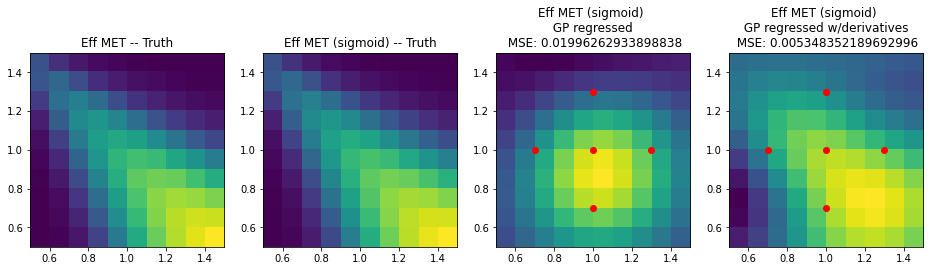

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
ax = axs.ravel()


axs[0].set_title("Eff MET -- Truth")
axs[0].imshow(y_true.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
#axs[0].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)


axs[1].set_title("Eff MET (sigmoid) -- Truth")
axs[1].imshow(y_test.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
#axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# ----- Regular GP ----- #
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)

axs[2].set_title("Eff MET (sigmoid) \n GP regressed \n MSE: {}".format(mse))
axs[2].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[2].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# -- Now with derivatives -- #
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train, dy=dy_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)

axs[3].set_title("Eff MET (sigmoid) \n GP regressed w/derivatives \n MSE: {}".format(mse))
axs[3].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[3].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

plt.savefig("MSE")

In [8]:
gp.kernel_

Constant(0.223**2) * RBF(length_scale=0.354) + WhiteKernel_X(noise_level=0.000289) + WhiteKernel_dX(noise_level=1e-05)